# HW4 - Tiny Autoencoder / VAE

Question: why do modern text-to-image models generate latents instead of pixels?


> CPU smoke run: this notebook is designed to execute quickly on CPU to verify mechanics, tensor shapes, plotting, and sampler logic. Generated samples may look like noise because the default training loop is intentionally tiny. Treat noisy samples as undertraining, not as evidence that the method is wrong. For meaningful visual quality, run longer on a GPU by increasing training steps, batch size, diffusion steps, and model width.


Sources:

- Latent Diffusion: https://arxiv.org/abs/2112.10752
- Qwen-Image-VAE-2.0: https://arxiv.org/abs/2605.13565


In [1]:
import math
import random
from pathlib import Path
from io import BytesIO

import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from IPython.display import Image, display

torch.manual_seed(7)
random.seed(7)
torch.set_num_threads(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


def show_plot():
    fig = plt.gcf()
    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=120)
    display(Image(data=buf.getvalue()))
    plt.close(fig)


device: cpu


In [2]:
COLORS = {
    "red": torch.tensor([1.0, 0.08, 0.08]),
    "green": torch.tensor([0.08, 0.80, 0.20]),
    "blue": torch.tensor([0.08, 0.25, 1.0]),
    "yellow": torch.tensor([1.0, 0.88, 0.08]),
}
SHAPES = ["circle", "square", "triangle"]


def draw_triangle(xx, yy, scale):
    # Upright triangle mask in normalized coordinates.
    top = yy > -scale
    left = yy < 2 * scale * (xx + scale)
    right = yy < -2 * scale * (xx - scale)
    return top & left & right & (yy < scale)


def make_shape_batch(batch=64, size=32, with_text=True):
    yy, xx = torch.meshgrid(
        torch.linspace(-1, 1, size),
        torch.linspace(-1, 1, size),
        indexing="ij",
    )
    images, captions = [], []
    for _ in range(batch):
        color_name = random.choice(list(COLORS))
        shape_name = random.choice(SHAPES)
        color = COLORS[color_name][:, None]
        scale = random.uniform(0.42, 0.72)
        img = torch.zeros(3, size, size)
        if shape_name == "circle":
            mask = xx.square() + yy.square() < scale**2
        elif shape_name == "square":
            mask = (xx.abs() < scale) & (yy.abs() < scale)
        else:
            mask = draw_triangle(xx, yy, scale)
        img[:, mask] = color
        images.append(img)
        captions.append(f"{color_name} {shape_name}")
    images = torch.stack(images)
    return (images, captions) if with_text else images


def show_images(images, titles=None, n=16, size=2.0):
    images = images.detach().cpu().clamp(0, 1)
    n = min(n, images.shape[0])
    cols = min(8, n)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * size, rows * size))
    axes = [axes] if n == 1 else axes.reshape(-1)
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(images[i].permute(1, 2, 0))
            if titles:
                ax.set_title(titles[i], fontsize=8)
    plt.tight_layout()
    show_plot()


In [3]:
class TinyVAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1), nn.SiLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.SiLU(),
            nn.Flatten(),
        )
        self.to_mu = nn.Linear(64 * 8 * 8, latent_dim)
        self.to_logvar = nn.Linear(64 * 8 * 8, latent_dim)
        self.from_z = nn.Linear(latent_dim, 64 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 8, 8)),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.SiLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.to_mu(h), self.to_logvar(h).clamp(-8, 8)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def decode(self, z):
        return self.decoder(self.from_z(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


vae = TinyVAE(latent_dim=64).to(device)
opt = torch.optim.AdamW(vae.parameters(), lr=2e-3)


0 recon 0.2461 kl 0.0003
10 recon 0.1013 kl 35.3239


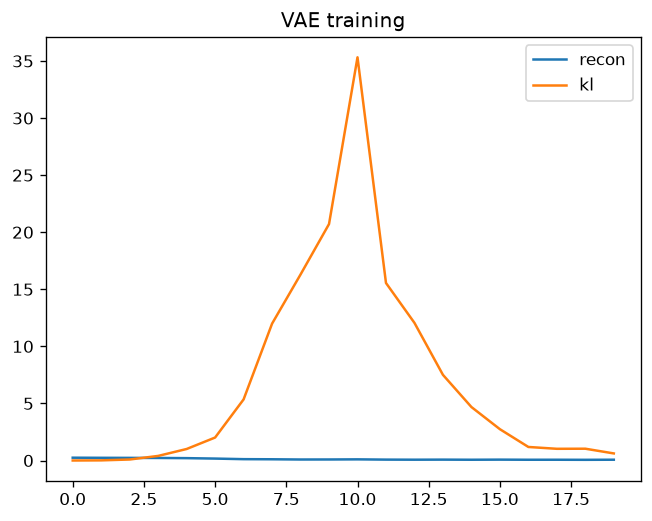

In [4]:
losses = []
for step in range(20):
    x = make_shape_batch(8, with_text=False).to(device)
    recon, mu, logvar = vae(x)
    recon_loss = F.mse_loss(recon, x)
    kl = -0.5 * torch.mean(1 + logvar - mu.square() - logvar.exp())
    loss = recon_loss + 0.001 * kl
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append((recon_loss.item(), kl.item()))
    if step % 10 == 0:
        print(step, "recon", round(recon_loss.item(), 4), "kl", round(kl.item(), 4))

plt.plot([x for x, _ in losses], label="recon")
plt.plot([k for _, k in losses], label="kl")
plt.legend()
plt.title("VAE training")
show_plot()


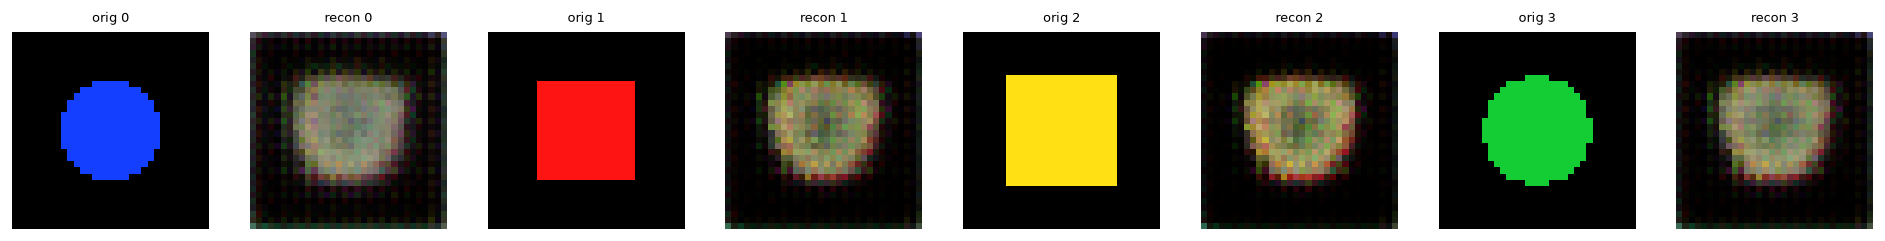

latent shape: torch.Size([8, 64])


In [5]:
test = make_shape_batch(8, with_text=False).to(device)
with torch.no_grad():
    recon, mu, logvar = vae(test)
pair = torch.stack([test[:4].cpu(), recon[:4].cpu()], dim=1).reshape(-1, 3, 32, 32)
titles = sum(([f"orig {i}", f"recon {i}"] for i in range(4)), [])
show_images(pair, titles=titles, n=8)
print("latent shape:", mu.shape)


## What To Look For

- Blurry edges mean the latent bottleneck is losing spatial detail.
- Color mistakes mean semantics are not reliably preserved.
- Qwen-Image-VAE-2.0 emphasizes both reconstruction fidelity and diffusability: the latent must reconstruct well and also be easy for a generator to model.
